<a href="https://colab.research.google.com/github/atwalneelam43-star/Neelam/blob/main/ddos_ml_ann_mlp_colab_notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Applied Machine Learning – DDoS Detection (CIC-DDoS2019)

This notebook implements **6 algorithms** required for the coursework.

## Machine Learning
1. Logistic Regression  
2. Random Forest  
3. Support Vector Machine (SVM)  
4. K-Nearest Neighbors (KNN)

## Deep Learning
5. Artificial Neural Network (ANN)  
6. Multilayer Perceptron (MLP)

Dataset: CIC-DDoS2019


In [1]:

!pip install pandas numpy scikit-learn seaborn tensorflow matplotlib


In [2]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
import seaborn as sns


## Upload Dataset CSV

In [3]:

from google.colab import files
uploaded = files.upload()


Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [4]:

df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (225745, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Data Preprocessing

In [5]:
print(df.columns)


Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [6]:
print (df.shape)

(225745, 85)


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df = df.dropna()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)


In [9]:

X = df.drop('Label', axis=1)
y = df['Label']


## Feature Scaling

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Flow ID'] = le.fit_transform(df['Flow ID'])
df['Source IP'] = le.fit_transform(df['Source IP'])
df['Destination IP'] = le.fit_transform(df['Destination IP'])
df['Timestamp'] = le.fit_transform(df['Timestamp'])

In [11]:
X = X.apply(lambda col: pd.factorize(col)[0] if col.dtype == 'object' else col)

In [12]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Train Test Split

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


## Evaluation Function

In [17]:

def evaluate_model(name, y_test, y_pred):

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(name)
    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

    return acc, pre, rec, f1


## Logistic Regression

Logistic Regression
Accuracy: 0.9993133845710869
Precision: 0.9991066920417913
Recall: 0.9996891030623348
F1 Score: 0.9993978127003244


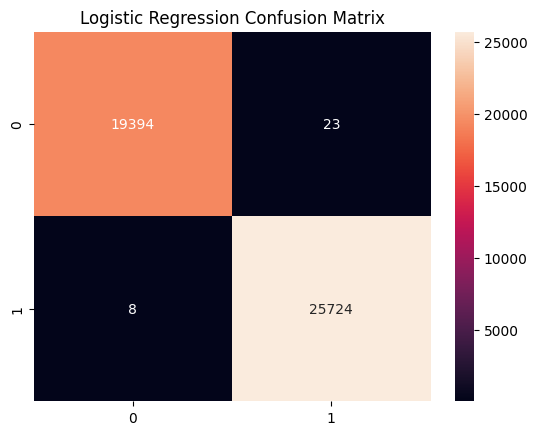

In [18]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_results = evaluate_model("Logistic Regression", y_test, y_pred_lr)


## Random Forest

Random Forest
Accuracy: 0.9999557022303927
Precision: 1.0
Recall: 0.9999222757655837
F1 Score: 0.999961136372469


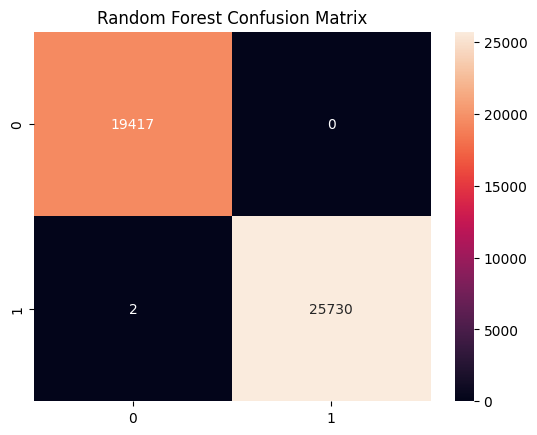

In [19]:

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)


## Support Vector Machine

SVM
Accuracy: 0.9998671066911781
Precision: 0.999961131840796
Recall: 0.9998056894139593
F1 Score: 0.9998834045860863


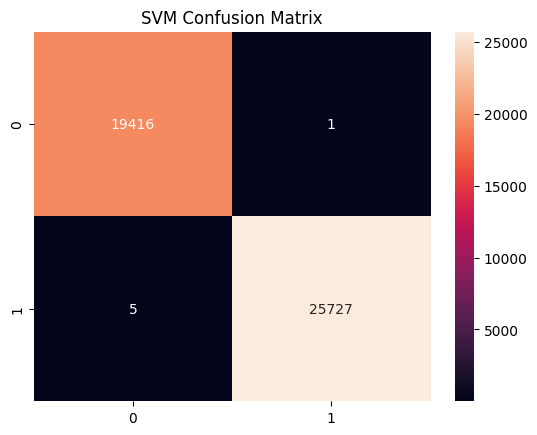

In [20]:

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_results = evaluate_model("SVM", y_test, y_pred_svm)


## K-Nearest Neighbors

KNN
Accuracy: 0.9998892555759817
Precision: 0.9999222727449381
Recall: 0.9998834136483755
F1 Score: 0.9999028428191128


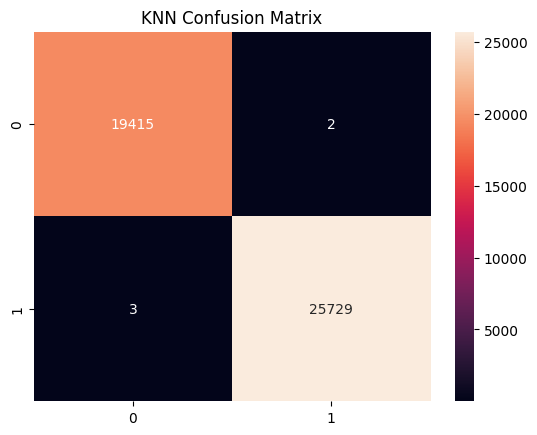

In [21]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_results = evaluate_model("KNN", y_test, y_pred_knn)


## Artificial Neural Network (ANN)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9989 - loss: 0.0068
Epoch 2/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9999 - loss: 6.3024e-04
Epoch 3/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 3.6883e-04
Epoch 4/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 1.4402e-04
Epoch 5/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 3.6245e-04
Epoch 6/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 2.2248e-04
Epoch 7/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 8.2036e-05
Epoch 8/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 4.3029e-04
Epoch 9/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 1.1003e-04
Epoch 10/10
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 1.0000 - loss: 1.7718e-04
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
ANN
Accuracy: 0.9999114044607854
Precisi

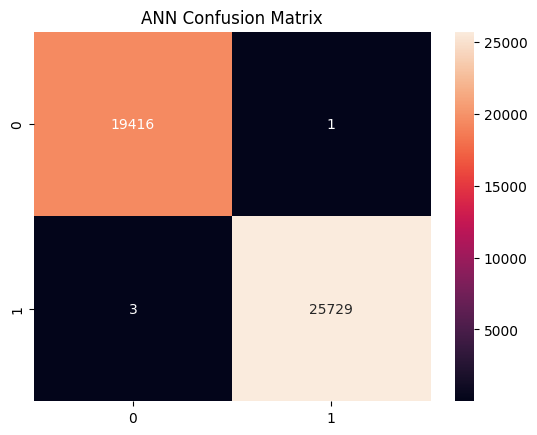

In [22]:

ann = Sequential()

ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=10, batch_size=64)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)
ann_results = evaluate_model("ANN", y_test, y_pred_ann)


## Multilayer Perceptron (MLP)

MLP
Accuracy: 0.9999335533455891
Precision: 0.999961136372469
Recall: 0.9999222757655837
F1 Score: 0.9999417056914677


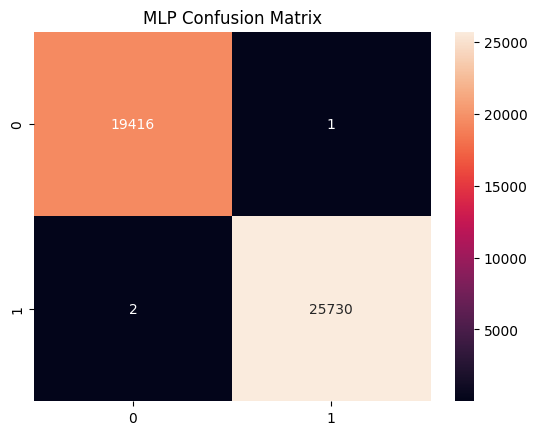

In [23]:

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64,32),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
mlp_results = evaluate_model("MLP", y_test, y_pred_mlp)


## Model Comparison

In [24]:

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "KNN",
        "ANN",
        "MLP"
    ],
    "Accuracy":[
        lr_results[0],
        rf_results[0],
        svm_results[0],
        knn_results[0],
        ann_results[0],
        mlp_results[0]
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.999313
1,Random Forest,0.999956
2,SVM,0.999867
3,KNN,0.999889
4,ANN,0.999911
5,MLP,0.999934


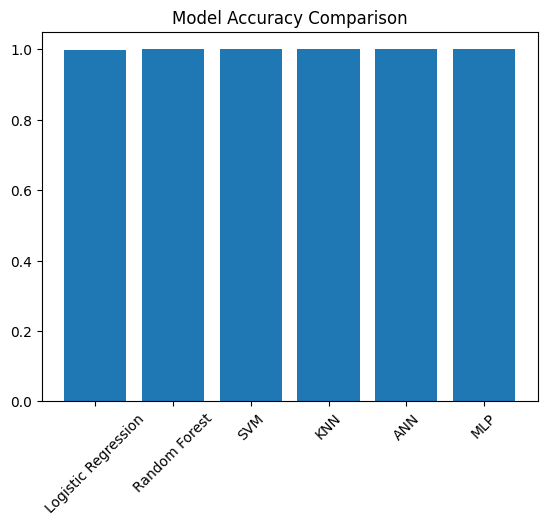

In [25]:

plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()
